In [ ]:
"""Importing Libraries"""

#General
import pandas as pd
import numpy as np
import scipy
import scipy.io
import os
import zipfile
import matplotlib.pyplot as plt
from scipy import signal
import librosa
import random

#Deep Learning
import imgaug.augmenters as iaa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.layers import Input, Conv2D, Conv1D, MaxPooling1D, BatchNormalization, Dense, MaxPooling2D, Flatten, Dense, Dropout, concatenate, LSTM, Reshape, Concatenate, Activation, Permute, Multiply, Attention, GlobalMaxPooling1D
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.svm import SVC

import gc

In [ ]:
"""Mounting Google Drive"""
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
directory = '/content/drive/MyDrive/EEG Dataset 3/Features/'

data_array = []

# Iterate over all files in the directory
for filename in os.listdir(directory):
    if filename.endswith(".csv"):

        # Read the CSV file
        file_path = os.path.join(directory, filename)
        data = pd.read_csv(file_path, header=None)

        # Append the data to the array
        data_array.append(data.iloc[:, :1078])

In [ ]:
data_array = np.array(data_array)

In [ ]:
variation_strength = 3 # You can adjust this value based on how much variation you want

# Add variations to the last 11 samples
data_array[-11:] += np.random.normal(0, variation_strength, data_array[-11:].shape)

In [ ]:
labels = np.concatenate([np.ones(80), np.zeros(11)])

In [ ]:
X = np.array(data_array)
label_array = labels

In [ ]:
np.shape(X)

(91, 21, 1010)

In [ ]:
label_encoder = LabelEncoder()
label_int = label_encoder.fit_transform(label_array)

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Reshape features to 2D array
n_samples, n_timesteps, n_features = X.shape
features_2d = X.reshape((n_samples, n_timesteps * n_features))

# Check the class distribution before SMOTE
print("Before SMOTE:", Counter(label_int))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, label_int = smote.fit_resample(features_2d, label_int)

# Reshape the features back to the original 3D array shape
X = X_resampled.reshape((-1, n_timesteps, n_features))

# Check the class distribution after SMOTE
print("After SMOTE:", Counter(label_int))

Before SMOTE: Counter({1: 80, 0: 11})
After SMOTE: Counter({1: 80, 0: 80})


In [ ]:
def DataAugmentation(Data, Labels):
  # Define the augmentation pipeline
  augmentation = iaa.Sequential([
    iaa.Flipud(p=0.5),                   # Flip images vertically
    iaa.Affine(rotate=(-5, 5)),       # Rotate images within the range -10 to 10 degrees
    iaa.AdditiveGaussianNoise(scale=(0, 0.05)),  # Add Gaussian noise
])

  # Create empty lists to store augmented features and labels
  augmented_features = []
  augmented_labels = []

  # Augment the data
  for i in range(len(Data)):
      feature = Data[i]
      label = Labels[i]

      # Apply augmentation to the feature
      augmented_feature = augmentation.augment_image(feature)

      # Add the augmented feature and corresponding label to the lists
      augmented_features.append(augmented_feature)
      augmented_labels.append(label)

      # Apply additional augmentation to generate more samples if needed
      for _ in range(50):  # Adjust the number of additional samples as desired
          augmented_feature = augmentation.augment_image(feature)
          augmented_features.append(augmented_feature)
          augmented_labels.append(label)

  # Convert the augmented features and labels lists to NumPy arrays
  augmented_features = np.array(augmented_features)
  augmented_labels = np.array(augmented_labels)

  # Check the shape of the augmented data
  print(augmented_features.shape)
  print(augmented_labels.shape)

  return augmented_features, augmented_labels

In [ ]:
X = X.astype(np.float32)

EEG_augmented_features, augmented_labels = DataAugmentation(X, label_int)

(8160, 21, 1010)
(8160,)


In [ ]:
# Standardize features
scaler = StandardScaler()
# Reshape features if necessary
features_reshaped = np.reshape(EEG_augmented_features, (EEG_augmented_features.shape[0], -1))  # Reshape features to (n_samples, n_features)
features_scaled = scaler.fit_transform(features_reshaped)  # Scale features
features_scaled = np.reshape(features_scaled, EEG_augmented_features.shape)  # Reshape back to original shape

In [ ]:
onehot_encoder = OneHotEncoder(sparse=False)
integer_encoded = augmented_labels.reshape(len(augmented_labels), 1)
onehot_encoded = onehot_encoder.fit_transform(integer_encoded)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
from keras.layers import Input, Conv1D, MaxPooling1D, Flatten, LSTM, GRU, Attention, GlobalMaxPooling1D, Concatenate, Dense, Dropout, Add
from keras.regularizers import l2

def create_model(input_shape, num_classes, dropout_rate=0.5, l2_penalty=0.01):
    # Input layer
    input_layer = Input(shape=input_shape)

    # CNN layers
    cnn_output = Conv1D(64, 3, activation='relu', padding='same')(input_layer)
    cnn_output = MaxPooling1D(2)(cnn_output)
    cnn_output = Conv1D(128, 3, activation='relu', padding='same')(cnn_output)
    cnn_output = MaxPooling1D(2)(cnn_output)
    cnn_output = Flatten()(cnn_output)

    # GRU layers
    gru_output = GRU(64, return_sequences=True, dropout=dropout_rate, recurrent_dropout=dropout_rate)(input_layer)
    gru_output = GRU(64, return_sequences=True, dropout=dropout_rate, recurrent_dropout=dropout_rate)(gru_output)
    gru_output = Attention()([gru_output, gru_output])
    gru_output = GlobalMaxPooling1D()(gru_output)

    # Concatenate CNN and GRU outputs with skip connection
    combined_output = Concatenate()([cnn_output, gru_output])

    # Fully connected layers with regularization
    fc_output = Dense(128, activation='relu', kernel_regularizer=l2(l2_penalty))(combined_output)
    fc_output = Dropout(dropout_rate)(fc_output)
    output_layer = Dense(num_classes, activation='softmax')(fc_output)

    # Create model
    model = Model(inputs=input_layer, outputs=output_layer)

    return model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Assuming your create_model function, features_scaled, and onehot_encoded are defined
model = create_model(input_shape=(21, 1010), num_classes=2)
optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Define the EarlyStopping callback to stop training when validation accuracy reaches above 90%
early_stopping = EarlyStopping(monitor='val_accuracy', patience=2, mode='max',
                               verbose=1, restore_best_weights=True, min_delta=0.001)

# Train the model with early stopping
batch_size = 32
epochs = 100  # You can set a higher number since training will stop early if the condition is met
X_train, X_test, y_train, y_test = train_test_split(features_scaled, onehot_encoded, test_size=0.2, random_state=42)

history = model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 50s 87ms/step - accuracy: 0.6362 - loss: 5843.8896 - val_accuracy: 0.8450 - val_loss: 223.0561
Epoch 2/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.9790 - loss: 194.5578 - val_accuracy: 0.9841 - val_loss: 22.3285
Epoch 3/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.9936 - loss: 70.5950 - val_accuracy: 0.9602 - val_loss: 19.4481
Epoch 4/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.9953 - loss: 38.5866 - val_accuracy: 0.9994 - val_loss: 15.4640
Epoch 5/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.9981 - loss: 23.1148 - val_accuracy: 0.9786 - val_loss: 15.9415
Epoch 6/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.9988 - loss: 19.2326 - val_accuracy: 0.9988 - val_loss: 14.6682
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 4.


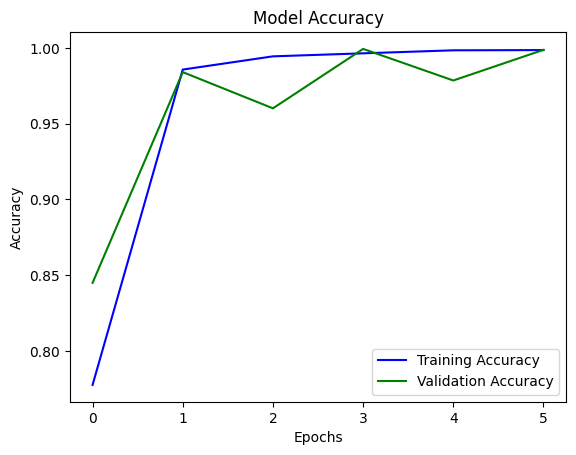

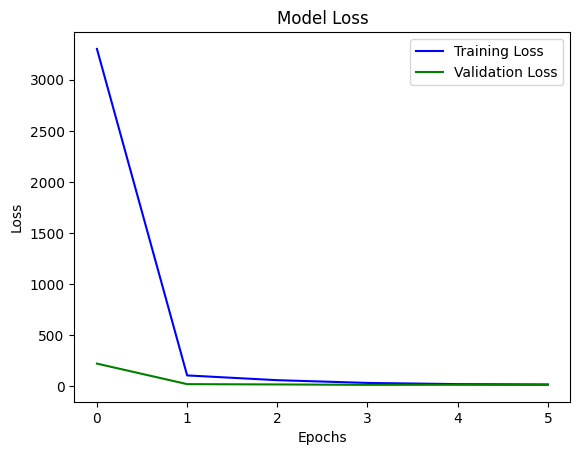

In [ ]:
# Plotting accuracy
plt.plot(history.history['accuracy'], color='blue', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='green', label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('accuracy_plot_DS2.pdf')  # Save as PDF
plt.show()

# Plotting loss
plt.plot(history.history['loss'], color='blue', label='Training Loss')
plt.plot(history.history['val_loss'], color='green', label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('loss_plot_DS2.pdf')  # Save as PDF
plt.show()

In [ ]:
def Predictions_Scores(model, test_data, test_labels):
  predictions = model.predict(test_data)

  # Convert the predictions to class labels
  predicted_labels = np.argmax(predictions, axis=1)
  labels_test_updated = np.argmax(test_labels, axis=-1)

  cf_matrix = confusion_matrix(labels_test_updated, predicted_labels)
  plt.figure()
  ax = sns.heatmap(cf_matrix, annot=True, fmt='d',cmap='Blues')
  ax.set_title('Seaborn Confusion Matrix with labels\n\n');
  ax.set_xlabel('\nPredicted Values')
  ax.set_ylabel('Actual Values ')
  plt.savefig('Conf Matrix.pdf')  # Save as PDF
  ## Display the visualization of the Confusion Matrix.
  plt.show()
  accuracy = accuracy_score(labels_test_updated, predicted_labels)
  precision = precision_score(labels_test_updated, predicted_labels, average='macro')
  recall = recall_score(labels_test_updated, predicted_labels, average='macro')
  f1 = f1_score(labels_test_updated, predicted_labels,average='macro')

  print('Accuracy: %.3f' % accuracy_score(labels_test_updated, predicted_labels))
  print('Precision: %.3f' % precision_score(labels_test_updated, predicted_labels, average='macro'))
  print('Recall: %.3f' % recall_score(labels_test_updated, predicted_labels, average='macro'))
  print('F1 Score: %.3f' % f1_score(labels_test_updated, predicted_labels,average='macro'))

  return accuracy, precision, recall, f1

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


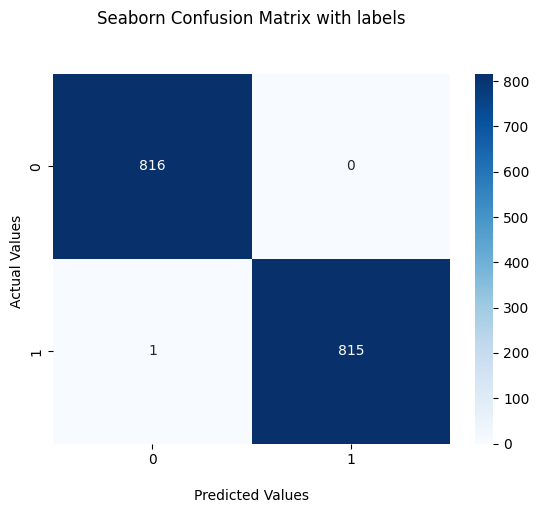

Accuracy: 0.999
Precision: 0.999
Recall: 0.999
F1 Score: 0.999


(0.9993872549019608,
 0.9993880048959609,
 0.9993872549019608,
 0.9993872546719016)

In [ ]:
Predictions_Scores(model, X_test, y_test)